In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as m

# Problem Set 6a

## 4.1

### a

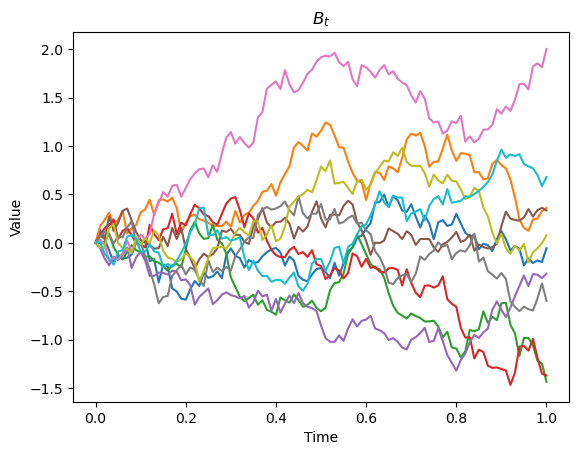

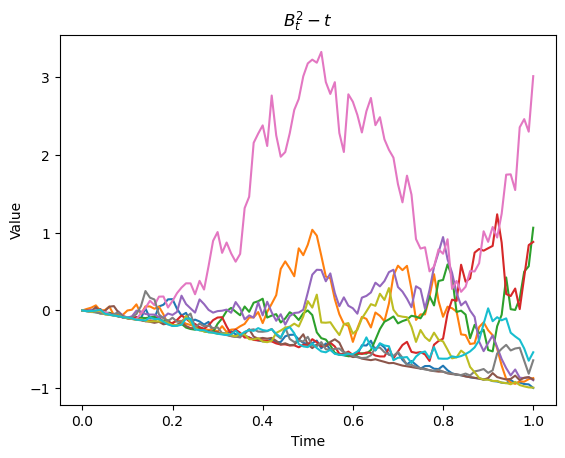

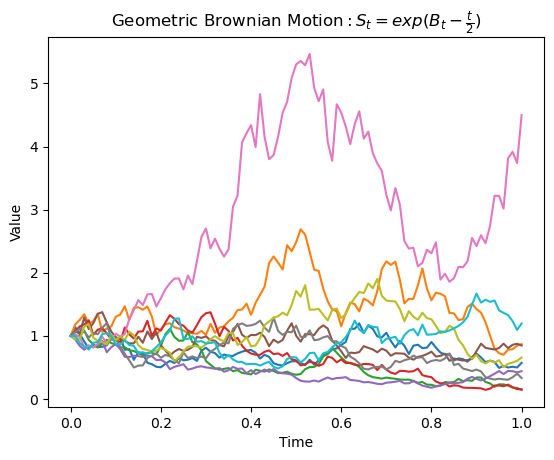

In [2]:
diff = 0.01

x = np.arange(0,1+diff,diff)

samples = np.random.normal(loc = 0, scale = m.sqrt(diff), size= (10,len(x) - 1))

samples = np.append(np.zeros(shape=(10,1)),samples, axis=1)

BM = np.cumsum(samples,axis=1)

BM_2_t = BM ** 2 - x

St = np.exp(BM - (x/2))

plt.plot(x,BM.T)
plt.title(r"$B_{t}$")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

plt.plot(x,BM_2_t.T)
plt.title(r"$B_{t}^2 - t$")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

plt.plot(x,St.T)
plt.title(r'$\text{Geometric Brownian Motion}: S_{t} = exp(B_{t} - \frac{t}{2})$')
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# plt.plot(x,np.mean(BM,axis=0), label=r'$B_{t}$')
# plt.plot(x, np.mean(BM_2_t, axis=0), label = r'$B_{t}^2 - t$')
# plt.plot(x, np.mean(St,axis=0), label = r'$exp(B_{t} - \frac{t}{2})$')
# plt.title("Means")
# plt.xlabel("Time")
# plt.ylabel("Mean")
# plt.axhline(0,linewidth = 0.5, color = 'red')
# plt.axhline(1,linewidth = 0.5,color = 'purple')
# plt.legend()
# plt.show()


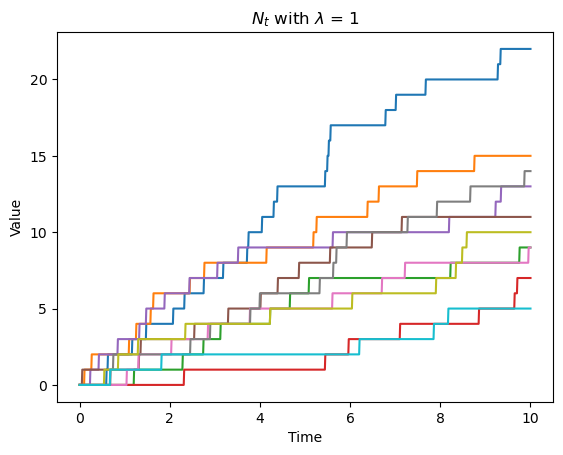

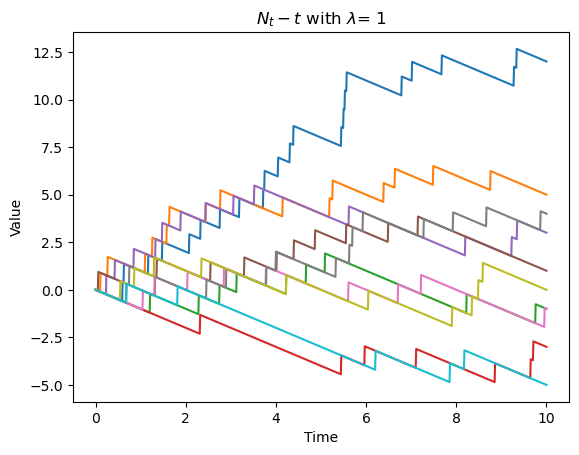

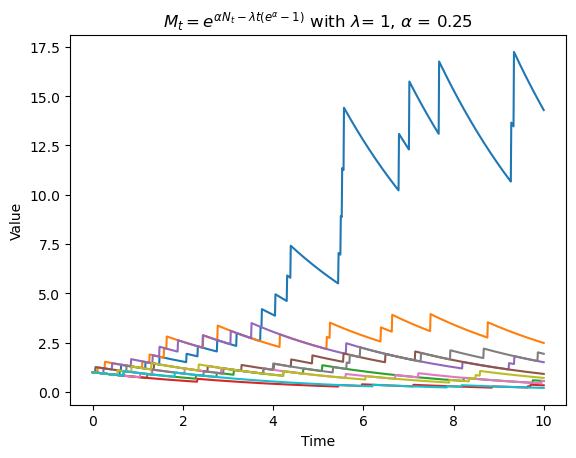

In [3]:
spacing = np.arange(0,10+diff,diff)
lamb = 1
alpha = .25

poi_samples = np.random.poisson(lam = lamb * diff, size=(10,len(spacing) - 1))

poi_samples = np.append(np.zeros(shape=(10,1)),poi_samples,axis=1)

N = np.cumsum(poi_samples,axis=1)

comp_N = N - (lamb * spacing)

Mt = np.exp((alpha * N) - (lamb * spacing * ((m.e ** alpha) - 1)))

plt.plot(spacing,N.T)
plt.title(fr"$N_{{t}}$ with $\lambda$ = {lamb}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

plt.plot(spacing,comp_N.T)
plt.title(fr"$N_{{t}} - t$ with $\lambda$= {lamb}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

plt.plot(spacing,Mt.T)
plt.title(fr"$M_{{t}} = e^{{\alpha N_{{t}} - \lambda t (e^{{\alpha}} -1)}}$ with $\lambda$= {lamb}, $\alpha$ = {alpha}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# plt.plot(spacing,np.mean(Mt,axis=0), label=r'$e^{{\alpha N_{{t}} - \lambda t (e^{{\alpha}} -1)}}$')
# plt.plot(spacing, np.mean(N, axis=0), label = r'$N_{{t}}$')
# plt.plot(spacing, np.mean(comp_N,axis=0), label = r'$N_{{t}} - t$')
# plt.title("Means")
# plt.xlabel("Time")
# plt.ylabel("Mean")
# plt.axhline(0,linewidth = 0.5, color = 'red')
# plt.axhline(1,linewidth = 0.5,color = 'purple')
# plt.legend()
# plt.show()



## 4.4

### a

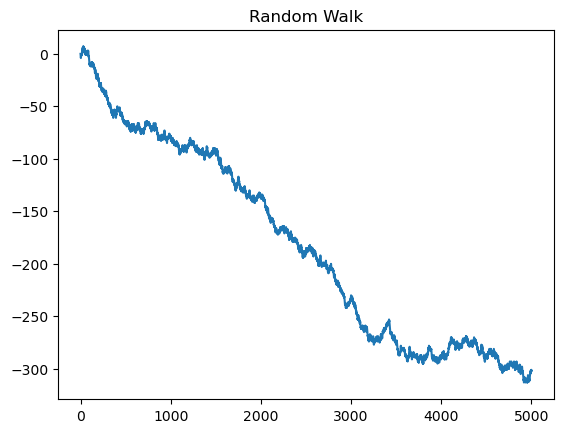

In [4]:
def randomWalk(start: int, paths: int, max_time: int = 5000, high: int = 200, low: int = 0):
    if max_time > 0:
        times = np.arange(0,5001,1)
        steps = np.random.choice(a=[1,-1],p=[18/38, 20/38], size=(paths,len(times)-1))
        trajectory = np.append(np.zeros(shape=(paths,1)) + start, steps, axis=1)
        return times, np.cumsum(trajectory,axis=1)
    times_high = 0
    times_low = 0
    for _ in range(paths):
        done = False
        this_path = [start]
        while (not done):
            step = np.random.choice(a=[1,-1],p=[18/38, 20/38])
            pos = this_path[-1] + step
            this_path.append(pos)
            if (pos == high or pos == low):
                done = True
        if pos == high:
            times_high += 1
        elif pos == low:
            times_low += 1
    return times_high / (times_high + times_low)
    
            


x,paths = randomWalk(0,1)

plt.plot(x,paths.T)
plt.title("Random Walk")
plt.show()


### b

In [5]:
x,paths = randomWalk(100,100)

hit_200 = (paths >= 200)
hit_0 = (paths <= 0)

first_200 = np.where(hit_200.any(axis=1), hit_200.argmax(axis=1), 5001)
first_0 = np.where(hit_0.any(axis=1), hit_0.argmax(axis=1), 5001)

result = first_200 < first_0

print("Probability of hitting 200 before 0 starting at 100 with 100 paths: ", np.mean(result))

Probability of hitting 200 before 0 starting at 100 with 100 paths:  0.0


### c

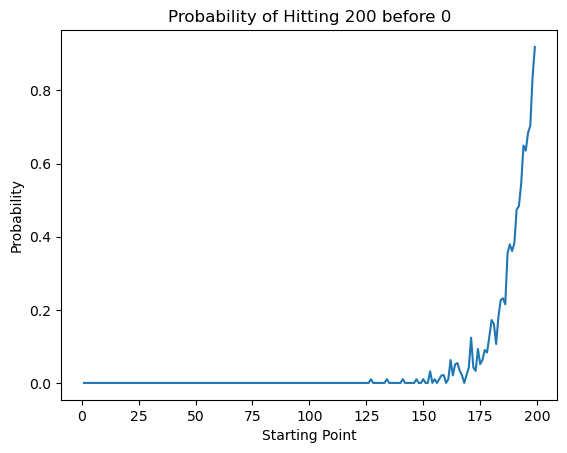

In [6]:
probs = []
probs2 = []
for i in range(1,200):
    x,paths = randomWalk(i,100)
    hit_200 = (paths >= 200)
    hit_0 = (paths <= 0)

    first_200 = np.where(hit_200.any(axis=1), hit_200.argmax(axis=1), 50001)
    first_0 = np.where(hit_0.any(axis=1), hit_0.argmax(axis=1), 50001)

    first_u = first_200[first_200 != first_0]
    first_l = first_0[first_200 != first_0]

    # print(len(first_u), len(first_l))

    result = first_u < first_l
    result2 = first_200 < first_0
    probs.append(np.count_nonzero(result)/len(result))
    probs2.append(np.count_nonzero(result2)/len(result2))

# x = []
# probs3 = []
# for i in range(1,200):
#     print(i)
#     x.append(i)
#     probs3.append(randomWalk(i,100,-1,200,0))
    

plt.plot(np.arange(1,200),np.array(probs),label = "Hit")
# plt.plot(np.arange(1,200),np.array(probs2), label = "Not Hit")
plt.title("Probability of Hitting 200 before 0")
plt.xlabel("Starting Point")
plt.ylabel("Probability")
plt.show()

# plt.plot(np.arange(1,200),np.array(probs3))
# plt.title("Probability of Hitting 200 before 0")
# plt.xlabel("Starting Point")
# plt.ylabel("Probability")
# plt.show()



In [7]:
# x = []
# probs3 = []
# for i in range(101,200):
#     print(i)
#     x.append(i)
#     probs3.append(randomWalk(i,120,-1,200,100))

# plt.plot(x,np.array(probs3))
# plt.title("Probability of Hitting 200 before 0")
# plt.xlabel("Starting Point")
# plt.ylabel("Probability")
# plt.axvline(193, color = 'red', linewidth = 0.5)
# plt.axhline(0.5, color = 'red', linewidth = 0.5)
# plt.show()